In [1]:
import os
from pathlib import Path

# 1. Jupyter Notebook inside VS Code: VS Code injects this global variable
if "__vsc_ipynb_file__" in globals():
    nb_dir = Path(__vsc_ipynb_file__).resolve().parent

# 2. Run directly as an .ipy or .py script: __file__ is available
elif "__file__" in globals():
    nb_dir = Path(__file__).resolve().parent

# 3. Plain JupyterLab / Jupyter Notebook environment
#    the kernel starts with cwd set to the notebook directory (unless it was changed manually)
else:
    nb_dir = Path(os.getcwd())

os.chdir(nb_dir)
print(f"Current working directory set to: {os.getcwd()}")

Current working directory set to: <repository>/scripts/exp_process


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.ndimage import gaussian_filter1d, grey_erosion
from scipy.optimize import nnls

plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True, linewidth=200)
print("OK")

OK


# Reference spectra

Reference spectrum shapes: {'meoh': (1646,), 'mpda': (1646,), 'mdnb': (1646,), 'mNA': (1646,)}


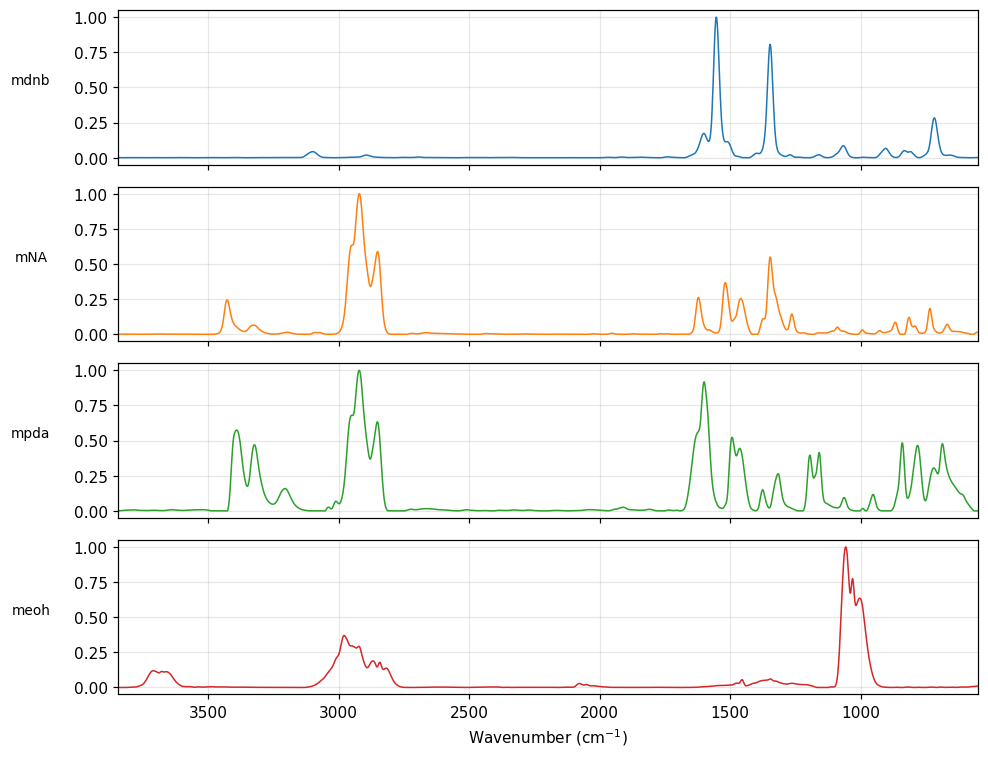

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d, grey_erosion
import json

# ---- read the reference spectra from JSON ----
with open("./digitized_results.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

x_ref = np.asarray(raw["mdnb"]["x"], dtype=float)      # 552–3842, dv=2

# ---- preprocessing: smoothing + baseline removal + normalisation ----
def prep_reference(y, sigma=2.5, win=61, base_sigma=30.0):
    ys   = gaussian_filter1d(np.asarray(y, float), sigma=sigma)
    base = gaussian_filter1d(
        grey_erosion(ys, size=(win,), mode="nearest"), sigma=base_sigma
    )
    yb = np.maximum(ys - base, 0.0)
    return yb / yb.max()

refs = {k: prep_reference(v["y"]) for k, v in raw.items()}
species = ["mdnb", "mNA", "mpda", "meoh"]
print("Reference spectrum shapes:", {k: v.shape for k, v in refs.items()})

# ---- plot the reference spectra ----
fig, ax = plt.subplots(4, 1, figsize=(9, 7), sharex=True)
for ax_, k, c in zip(ax, species, ["C0", "C1", "C2", "C3"]):
    ax_.plot(x_ref, refs[k], color=c, lw=1.0)
    ax_.set_ylabel(k, rotation=0, labelpad=28, fontsize=9)
    ax_.set_xlim(3844, 552)
    ax_.grid(alpha=0.3)
ax[-1].set_xlabel("Wavenumber (cm$^{-1}$)")
plt.tight_layout()
plt.show()

## 4. MCR-ALS: reference-guided alternating non-negative least squares

Read ./exp_ftir_snapshots.csv: D.shape=(28, 1646), x∈[552.0, 3842.0] cm^-1, t∈[0.000, 0.500] min
ST0 shape: (4, 1646)
MCR-ALS converged: n_iter=80  R2(global)=0.995723  R2(temporal)=0.49841  RMSE=0.003958
Correlation between resolved and reference spectra: [0.9788, 0.9998, 0.9929, 0.9957]


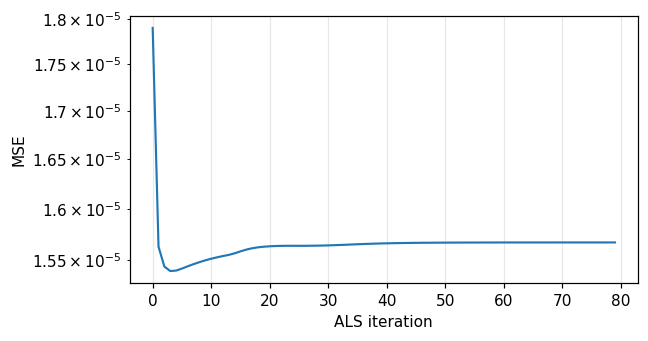

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import nnls

# ==================== 1. read the experimental spectra back from the CSV ====================
fname = "./exp_ftir_snapshots.csv"
with open(fname) as f:
    header = f.readline().strip().split(",")          # first column is time_min, the rest are wavenumbers
arr = np.loadtxt(fname, delimiter=",", skiprows=1)

t = arr[:, 0]                                         # scan time (min)
D = arr[:, 1:]                                        # (N_SCANS, n)
x = np.array([float(v) for v in header[1:]])          # wavenumber (cm^-1)
N_SCANS, n = D.shape
print(f"Read {fname}: D.shape={D.shape}, "
      f"x∈[{x.min():.1f}, {x.max():.1f}] cm^-1, "
      f"t∈[{t[0]:.3f}, {t[-1]:.3f}] min")

# ==================== 2. interpolate the reference spectra onto the CSV x grid ====================
# the reference x may be descending; np.interp requires monotonically increasing x
order        = np.argsort(x_ref)
x_ref_sorted = x_ref[order]

ST0 = np.stack([
    np.interp(x, x_ref_sorted, refs[k][order], left=0.0, right=0.0)
    for k in species
])                                                     # (4, n), row order = species
print("ST0 shape:", ST0.shape)

# ==================== 3. MCR-ALS ====================
def mcr_als(D, ST0, lam=0.04, n_iter=80):
    k  = ST0.shape[0]
    ST = ST0.copy()
    history = []
    for it in range(n_iter):
        # C step: NNLS per scan
        Cm = np.stack([nnls(ST.T, D[i])[0] for i in range(D.shape[0])])
        # S step: NNLS with Tikhonov regularisation
        A = np.vstack([Cm, np.sqrt(lam) * np.eye(k)])
        B = np.vstack([D,  np.sqrt(lam) * ST0])
        ST = np.stack([nnls(A, B[:, j])[0] for j in range(D.shape[1])]).T
        ST = ST / np.maximum(ST.max(1, keepdims=True), 1e-12)
        history.append(float(((D - Cm @ ST) ** 2).mean()))
    Cm = np.stack([nnls(ST.T, D[i])[0] for i in range(D.shape[0])])
    return Cm, ST, np.array(history)

Cc, ST, hist = mcr_als(D, ST0)
Drec  = Cc @ ST
resid = D - Drec

r2_global   = 1 - np.sum(resid**2) / np.sum(D**2)
r2_temporal = 1 - np.sum(resid**2) / np.sum((D - D.mean(0))**2)
rmse = np.sqrt((resid**2).mean())
corr = [float(np.corrcoef(ST[j], ST0[j])[0, 1]) for j in range(4)]
print(f"MCR-ALS converged: n_iter={len(hist)}  "
      f"R2(global)={r2_global:.6f}  R2(temporal)={r2_temporal:.5f}  RMSE={rmse:.6f}")
print("Correlation between resolved and reference spectra:", [round(c, 4) for c in corr])

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(hist, lw=1.4)
ax.set_yscale("log")
ax.set_xlabel("ALS iteration")
ax.set_ylabel("MSE")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# ---- save the MCR-ALS results ----
names4 = ["mDNB", "mNA", "mPDA", "MeOH"]

for j, name in enumerate(names4):                     
    np.savetxt(f"contrib_{name}.csv",
               np.column_stack([t, np.outer(Cc[:, j], ST[j])]),# 28 concentrations of one species * its resolved pure spectrum
               delimiter=",",
               header="time_min," + ",".join(f"{v:.3f}" for v in x), comments="", fmt="%.8f")

with open("resolved_component_spectra.csv", "w") as fh:  # the 4 resolved pure spectra (unit peak intensity)
    fh.write("species," + ",".join(f"{v:.3f}" for v in x) + "\n")
    for j, name in enumerate(names4):
        fh.write(name + "," + ",".join(f"{v:.8f}" for v in ST[j]) + "\n")

np.savetxt("resolved_concentrations.csv",                 # concatenate the time column t with the 4-component concentration matrix Cc resolved by MCR-ALS and save it as one CSV file.
           np.column_stack([t, Cc]),
           delimiter=",", header="time_min," + ",".join(names4), comments="", fmt="%.8f")

S = Cc[:, :3] @ ST[:3]                                  # per-scan component mixture spectra after removing the solvent
np.savetxt("resolved_solute_spectra.csv",               # S rebuilt from the first 3 columns and rows with MeOH removed: still 28x1646, but without the MeOH contribution
           np.column_stack([t, S]),
           delimiter=",",
           header="time_min," + ",".join(f"{v:.3f}" for v in x), comments="", fmt="%.8f")

meta = {
    "n_scans": int(N_SCANS),
    "time_range": [float(t[0]), float(t[-1])],
    "mcr": {"r2_global": float(r2_global), "r2_temporal": float(r2_temporal),
            "rmse": float(rmse), "corr_resolved_vs_reference": corr,
            "n_iter": int(len(hist)), "lam": 0.04},
    "refs": {k: {"x": x.tolist(), "y": refs[k].tolist()} for k in refs},
}
json.dump(meta, open("pipeline_meta.json", "w"), ensure_ascii=False, indent=2, default=float)

## 5. Output files

| File | Content |
|---|---|
| `contrib_mDNB/mNA/mPDA/MeOH.csv` | per-scan contribution spectra C_ij * ST_j of every component (same file names as before) |
| `resolved_solute_spectra.csv` | per-scan component mixture spectra after solvent removal (**intermediate product, not fed to the model**; the model only receives the 4 resolved pure spectra) |
| `resolved_component_spectra.csv` | the 4 MCR-ALS resolved pure spectra (unit peak intensity) |
| `resolved_concentrations.csv` | concentrations recovered by MCR-ALS (arbitrary scale) |
| `pipeline_meta.json` | fit quality (R2/RMSE/correlation) and the reference-spectrum data |

Next: `predict.ipynb` reads `resolved_component_spectra.csv` (the 4 resolved pure spectra) as the **only model input**, performs the law-of-total-probability synthesis with the experimental mole fractions, and produces the per-scan functional-group multiplicities and the figures.

# change the working directory

In [3]:
import os
os.chdir("../..")

In [4]:
#!/usr/bin/env python
from __future__ import annotations

import json
import os
import shutil
from dataclasses import replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

LAUNCH_DIR = Path.cwd()          # importing the ikan package changes cwd, so record the launch directory first
from ckan_specnet.core import Config, configure_torch_runtime, device_of
from ckan_specnet.eval import (
    load_manifest,
    predict_saved_ensemble_streaming,
    tasks_from_manifest,
)
os.chdir(LAUNCH_DIR)

configure_torch_runtime()
cfg = replace(Config(), test_parquet="exp_test", batch_size=1024, num_workers=0)
manifest = load_manifest(LAUNCH_DIR / 'models')
tasks = tasks_from_manifest(manifest)
RUN_DIR = LAUNCH_DIR / "models/"
EXPDIR = LAUNCH_DIR / "scripts/exp_process/"
print("tasks:", len(tasks.all), "| folds:", len(manifest["ensemble"]["fold_files"]))



 /opt/miniforge3/envs/spec/lib/python3.11/site-packages/ikan


/opt/miniforge3/envs/spec/lib/python3.11/site-packages/ikan/rational_triton.py:244: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/opt/miniforge3/envs/spec/lib/python3.11/site-packages/ikan/rational_triton.py:272: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_bwd
/opt/miniforge3/envs/spec/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tasks: 33 | folds: 5


/opt/miniforge3/envs/spec/lib/python3.11/site-packages/ikan/rational_triton2d.py:228: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/opt/miniforge3/envs/spec/lib/python3.11/site-packages/ikan/rational_triton2d.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_bwd


In [5]:
# ---------- 1. model input: only the 4 MCR-ALS resolved pure spectra (no mixture spectrum is fed) ----------
comp = pd.read_csv(EXPDIR / "resolved_component_spectra.csv")
species = comp["species"].to_list()                     # mDNB, mNA, mPDA, MeOH
ST = comp.drop(columns=["species"]).to_numpy().astype(np.float32)
print("Model input (resolved pure spectra):", ST.shape, species)

res = predict_saved_ensemble_streaming(
    run_dir=RUN_DIR, manifest=manifest, x=ST, tasks=tasks, cfg=cfg, device=device_of(),
)
np.savez_compressed(EXPDIR / "predictions_component_spectra.npz",
                    **{tsk: res["prob"][tsk] for tsk in res["prob"]})

P_nitro = res["prob"]["nitro_3class"]                   # 4 components x 3 classes
P_amines = res["prob"]["amines_4class"]                 # 4 components x 4 classes
neg_tasks = ["esters", "ketones", "alkyl_halides", "nitriles", "amides", "aldehydes", "alkyne"]

print("Component nitro distribution:", np.round(P_nitro, 4))
print("Component nitro argmax:", P_nitro.argmax(1), " (expected: m-DNB=2, m-NA=1, m-PDA=0, MeOH=0)")

print("Component amine distribution", np.round(P_amines, 4))
print("Component amine argmax:", P_amines.argmax(1))

# ---------- print the argmax of the 4 input pure spectra on every task ----------
print("\n=== argmax of the 4 input pure spectra on every task (max probability in parentheses) ===")
print(f"{'task':<18} " + "  ".join(f"{sp:<12}" for sp in species))
for tsk in res["prob"]:
    prob = np.asarray(res["prob"][tsk])
    am   = prob.argmax(1)
    pmax = prob.max(1)
    cells = [f"{am[i]}({pmax[i]:.2f})" for i in range(len(species))]
    print(f"{tsk:<18} " + "  ".join(f"{c:<12}" for c in cells))

# argmax matrix only
A = np.stack([np.asarray(res["prob"][tsk]).argmax(1) for tsk in res["prob"]])
print("\nargmax matrix (rows = task, columns = input spectrum):")
print("tasks:", list(res["prob"].keys()))
print(A)

Model input (resolved pure spectra): (4, 1646) ['mDNB', 'mNA', 'mPDA', 'MeOH']
Predicting fold 1/5: fold_1.pt
Predicting fold 2/5: fold_2.pt
Predicting fold 3/5: fold_3.pt
Predicting fold 4/5: fold_4.pt
Predicting fold 5/5: fold_5.pt
Component nitro distribution: [[0.0001 0.0072 0.9927]
 [0.0008 0.9992 0.    ]
 [1.     0.     0.    ]
 [1.     0.     0.    ]]
Component nitro argmax: [2 1 0 0]  (expected: m-DNB=2, m-NA=1, m-PDA=0, MeOH=0)
Component amine distribution [[0.9999 0.0001 0.     0.    ]
 [0.0001 0.9995 0.0004 0.    ]
 [0.     0.0785 0.9214 0.0001]
 [0.8414 0.1586 0.     0.    ]]
Component amine argmax: [0 1 2 0]

=== argmax of the 4 input pure spectra on every task (max probability in parentheses) ===
task               mDNB          mNA           mPDA          MeOH        
alkane             1(0.97)       0(0.81)       1(0.94)       1(1.00)     
alkene             0(0.98)       0(1.00)       0(1.00)       0(0.94)     
alkyne             0(1.00)       0(1.00)       0(1.00)    

In [6]:
import pandas as pd
import numpy as np

rows = []

# ---- nitro: 3 classes, listed class by class ----
prob = np.asarray(res["prob"]["nitro_3class"])
for cls, label in enumerate(["Nitro: Count=0", "Nitro: Count=1", "Nitro: Count>=2"]):
    row = {"task": label}
    for i, sp in enumerate(species):
        row[sp] = f"{prob[i, cls]:.4f}"
    rows.append(row)

# ---- amines: 4 classes, listed class by class ----
prob = np.asarray(res["prob"]["amines_4class"])
for cls in range(prob.shape[1]):
    row = {"task": f"Amines: Class {cls}"}
    for i, sp in enumerate(species):
        row[sp] = f"{prob[i, cls]:.4f}"
    rows.append(row)

# ---- aldehyde: binary, take the probability of present (class = 1) ----
prob = np.asarray(res["prob"]["alcohols"])
row = {"task": "Alcohols (present)"}
for i, sp in enumerate(species):
    row[sp] = f"{prob[i, 1]:.4f}"
rows.append(row)

# ---- aromatics: binary, take the probability of present (class = 1) ----
prob = np.asarray(res["prob"]["aromatics"])
row = {"task": "Aromatics (present)"}
for i, sp in enumerate(species):
    row[sp] = f"{prob[i, 1]:.4f}"
rows.append(row)

df = pd.DataFrame(rows)
df.columns = ['task', 'm-DNB', 'm-NA', 'm-PDA', 'MeOH']
print(df.to_string(index=False))
# df.to_csv(EXPDIR / "predictions_key_tasks.csv", index=False)

               task  m-DNB   m-NA  m-PDA   MeOH
     Nitro: Count=0 0.0001 0.0008 1.0000 1.0000
     Nitro: Count=1 0.0072 0.9992 0.0000 0.0000
    Nitro: Count>=2 0.9927 0.0000 0.0000 0.0000
    Amines: Class 0 0.9999 0.0001 0.0000 0.8414
    Amines: Class 1 0.0001 0.9995 0.0785 0.1586
    Amines: Class 2 0.0000 0.0004 0.9214 0.0000
    Amines: Class 3 0.0000 0.0000 0.0001 0.0000
 Alcohols (present) 0.0004 0.0000 0.0001 0.9667
Aromatics (present) 0.9947 0.9996 0.9921 0.0005


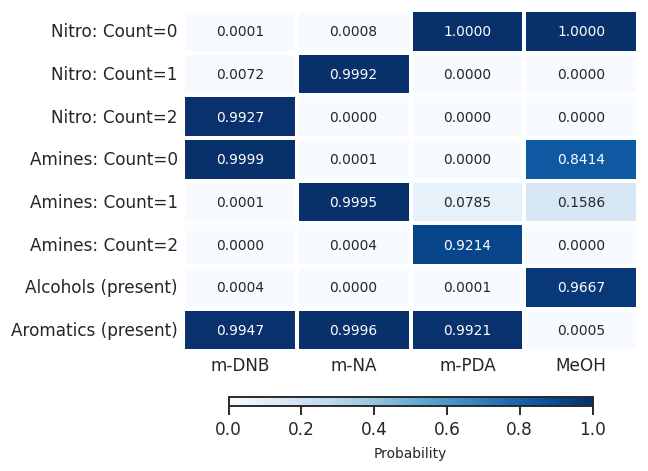

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# ========== code edits ==========
# 1. replace 'Nitro: Count>=2' in the task column with 'Nitro: Count=2'
df['task'] = df['task'].replace('Nitro: Count>=2', 'Nitro: Count=2')

# 2. drop the row whose task is 'Amines: Class 3'
df = df[df['task'] != 'Amines: Class 3'].reset_index(drop=True)

# 3. replace 'Amines: Class 0/1/2' in the task column with 'Amines: Count=0/1/2'
df['task'] = df['task'].str.replace('Amines: Class ', 'Amines: Count=')
# ==============================

# the rest is left unchanged
df_plot = df.set_index("task").astype(float)

# Nature style
sns.set_theme(style="white", font="sans-serif")
plt.rcParams['font.size'] = 10

fig, ax = plt.subplots(figsize=(6, 4.5))

sns.heatmap(
    df_plot,
    annot=True,
    fmt='.4f',
    cmap='Blues',
    vmin=0, vmax=1,
    linewidths=1.5,
    linecolor='white',
    cbar=False,
    ax=ax,
    annot_kws={"size": 9},
)

# bottom colorbar
cbar = fig.colorbar(
    ax.collections[0],
    ax=ax,
    orientation='horizontal',
    pad=0.1,
    aspect=40,
    shrink=0.8,
)
cbar.set_label('Probability', labelpad=5, fontsize=9)

ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='y', rotation=0, length=0)
ax.tick_params(axis='x', rotation=0, length=0)

plt.tight_layout()
# plt.savefig('nature_heatmap.pdf', dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()